### 1. Importación de librerías y setup inicial

En esta sección se cargan las librerías necesarias para el desarrollo del modelo ILP.  
Particularmente se usa *pandas* para manipulación de datos y *PuLP* para la formulación matemática y solución del problema de optimización.  
Este código también carga el directorio raíz donde se encuentran los archivos fuente de datos.

In [1]:
# Standard imports
import pandas as pd
from pathlib import Path
import re
from IPython.display import display

# Convenience
ROOT = Path('c:/Users/ASUS/Documents/bcol_prueba_2025') # assume notebook is run from repository root; adjust if needed
DATA_DIR = ROOT / 'data'
EXCEL_PATH = DATA_DIR / 'Metadatos_diccionario.xlsx'

### 2. Preparación del dataset analítico unificado

En este bloque se realizan los merges entre las diferentes tablas.  
Aquí se deja la base lista para poder calcular el tiempo total requerido por ejecutivo, ya que la unidad de decisión es el ejecutivo y no el cliente individual.

De esta consolidación se obtiene:
- listado final de ejecutivos
- capacidad disponible de cada gerente
- tiempo de atención asociado a cada ejecutivo (sumatoria del tiempo por cliente)

In [2]:
# Load the Excel file and show sheet names
if not EXCEL_PATH.exists():
    raise FileNotFoundError(f'Metadata Excel not found at {EXCEL_PATH}. Please verify path.')

xls = pd.ExcelFile(EXCEL_PATH)
sheets = xls.sheet_names
print('Found sheets:', sheets)

PANDAS_TYPE_MAP = {
    'bigint': 'Int64',   # nullable 64-bit integer
    'int':    'Int64',   # nullable integer
    'tinyint':'Int8',    # small nullable integer
    'string': 'string'   # pandas StringDtype (nullable)
}

# Display each sheet's first rows and columns for inspection
sheets_preview = {}
for name in sheets:
    try:
        df = xls.parse(name)
        if "Tipo" in df.columns:
            df = df.rename(columns={"Tipo": "type", "Nombre": "name"})
        if "name " in df.columns:
            df = df.rename(columns={"name ": "name"})
        df['type_pandas'] = df['type'].map(lambda t: PANDAS_TYPE_MAP.get(t.lower(), 'object') if isinstance(t, str) else 'object')
    except Exception as e:
        print(f'Could not parse sheet {name}: {e}')
        continue
    sheets_preview[name] = df.head(5)
    # print('--- Sheet:', name, '---')
    # print('Shape:', df.shape)
    # print('Columns:', list(df.columns))
    display(df.head(5))

Found sheets: ['pcac_mac_gpi_clientes', 'pcac_mac_gpi_ecas', 'pcac_mac_gpi_tenencia_prod', 'pcac_planta_comercial2', 'pcac_encuesta', 'pcac_capacidad_gerentes', 'pcac_oportunidades_comer']


,name,type,comment,type_pandas
0,num_doc_cli,bigint,Número de documento Cliente Preferencial,Int64
1,cod_tipo_doc_cli,tinyint,Código del tipo de documento Cliente Preferencial,Int8
2,num_doc_cli_dv,bigint,Número de documento Cliente Preferencial con d...,Int64
3,cli_val,tinyint,Si es cliente Valores,Int8
4,cli_pan,tinyint,Si es cliente Panamá,Int8


,name,type,comment,type_pandas
0,num_doc_gte_inv,bigint,Documento Gerente de Inversión,Int64
1,cod_gte_inv,bigint,Codigo del Gerente de Inversión,Int64
2,nombre_gte_inv,string,Nombre del Gerente,string
3,num_doc_ejec_bco,bigint,Documento del Ejecutivo del Gerente,Int64
4,cod_ejec_bco,bigint,Codigo del ejecutivo,Int64


,name,type,Unnamed: 2,type_pandas
0,num_doc_cli,bigint,Documento del cliente,Int64
1,cod_tipo_doc_cli,int,tipo de documento,Int64
2,num_doc_cli_dv,bigint,NaN,Int64
3,cod_prod,bigint,código del producto,Int64
4,nombre_prod,string,nombre del producto,string


,name,type,comment,type_pandas
0,num_doc_gte_inv,bigint,Número de documento Gerente Preferencial de In...,Int64
1,nombre_gte_inv,string,Nombre Gerente Preferencial de Inversiones,string
2,receptor_valores,string,Código del receptor Valores (código vendedor) ...,string
3,cod_gte_inv,int,Código de vendedor Bancolombia del Gerente,Int64
4,ciudad_gte_inv,string,Ciudad Gerente Preferencial de Inversiones,string


,name,type,type_pandas
0,nombre_comercial,string,string
1,cedula_comercial,bigint,Int64
2,codigo_de_vendedor,bigint,Int64
3,cod_producto,bigint,Int64
4,producto,string,string


,name,type,comment,type_pandas
0,cod_gte_inv,bigint,Código del gerente de inversión,Int64
1,cod_region_gte_inv,tinyint,código que representa la región donde se encue...,Int8
2,sistematica_anual,bigint,código general del proceso (obviar),Int64
3,tiempo_instrum_resta,bigint,tiempo general estimado de instrumentación de...,Int64
4,tiempo_restante,bigint,tiempo disponible para actividades comerciales...,Int64


,name,type,Descripción,type_pandas
0,num_doc_cli,bigint,Número de documento del cliente,Int64
1,cod_tipo_doc_cli,int,tipo de documento del cliente,Int64
2,id_oport,string,identificador de la oportunidad comercial,string
3,cat_oport,string,categoria de la oportunidad comercial,string
4,nombre_activo_oport,string,Nombre de la Oportunidad Comercial,string


In [3]:
dict_dataframes = {}

for name_table in sheets:
    try:
        types_table = zip(sheets_preview[name_table]['name'].to_list(),
            sheets_preview[name_table]['type_pandas'].to_list())
        path_table = DATA_DIR / (name_table + '.csv')
        dict_dataframes[name_table] = pd.read_csv(path_table, dtype=dict(types_table))
    except Exception as e:
        print(f'Could not load CSV for table {name_table}: {e}')

In [58]:
df_time_client = pd.read_csv(DATA_DIR / 'pcac_clientes_tiempo_estimado.csv')
print(df_time_client.shape)
df_time_client.head()

(34145, 15)


,num_doc_cli,cod_tipo_doc_cli,cod_ejec_bco,region_ejec_bco_1,cod_region_ejec_bco_1,region_ejec_bco,cod_region_ejec_bco,cod_gte_inv,num_doc_gte_inv,ciudad_gte_inv,region_gte_inv,cod_region_gte_inv,marca_mac_inv,score_modelo,minutos
0,792948952420445876,1,5011585778571550166,CARIBE,3.0,CARIBE,3,8648915042775491028,1872056861363575577,SANTA MARTA,CARIBE,3,B,0.19,131.121951
1,3972597626226801159,1,5011585778571550166,CARIBE,3.0,CARIBE,3,8648915042775491028,1872056861363575577,SANTA MARTA,CARIBE,3,B,0.06,60.390244
2,2753978090031414171,1,5011585778571550166,CARIBE,3.0,CARIBE,3,8648915042775491028,1872056861363575577,SANTA MARTA,CARIBE,3,B,0.12,79.707317
3,289615200991922439,1,5011585778571550166,CARIBE,3.0,CARIBE,3,8648915042775491028,1872056861363575577,SANTA MARTA,CARIBE,3,B,0.09,213.097561
4,3537185204720284636,1,5011585778571550166,CARIBE,3.0,CARIBE,3,8648915042775491028,1872056861363575577,SANTA MARTA,CARIBE,3,C,0.03,125.951220


### 3. Cálculo del valor comercial por ejecutivo
Aquí se construye la métrica que alimenta la función objetivo del modelo ILP.
Se combina:
- score promedio del ejecutivo
- tipo de clientes (A/B/C) ponderado con mayor prioridad hacia A y B
- cantidad de clientes
Este valor permite priorizar ejecutivos que contribuyen mayor retorno esperado antes que volumen bruto.
### Función: calcular_valor_ejecutivos(clientes_df)

Esta función calcula el valor objetivo (utility) asociado a cada ejecutivo.

*Qué hace:*
- Agrupa clientes por ejecutivo.
- Calcula score promedio por ejecutivo.
- Cuenta cuántos clientes tiene ese ejecutivo por cada categoría A / B / C.
- Genera una métrica final combinada que prioriza A y B por encima de C y que además incorpora score promedio para romper empates.
  
*Por qué es importante:*
Este valor es lo que finalmente se optimiza en el ILP.  
No se está optimizando tiempo directamente, sino potencial comercial ponderado → es decir: cuánto valor aporta asignar ese ejecutivo.

*Resultado que devuelve:*
Un dataframe con:
- ejecutivo
- score promedio
- cantidad A / B / C
- valor total final del ejecutivo (variable que entra como coeficiente de la función objetivo del ILP)

In [ ]:
def calcular_valor_ejecutivos(clientes_df):
    """
    Calcula el valor de cada ejecutivo basado en sus clientes
    """
    # Agrupar clientes por ejecutivo
    clientes_por_ejecutivo = clientes_df.groupby('cod_ejec_bco')
    clientes_por_ejecutivo_tiempo = df_time_client.groupby('cod_ejec_bco')['minutos'].sum().reset_index()
    
    
    ejecutivos_valor = []
    
    for ejecutivo, grupo in clientes_por_ejecutivo:
        # Información básica
        zona = grupo['region_ejec_bco'].iloc[0] if 'region_ejec_bco' in grupo.columns else 'DESCONOCIDA'
        
        # Métricas de valor
        # tiempo_total = 0
        suma_scores = 0
        suma_scores_AB = 0
        count_AB = 0
        count_total = len(grupo)
        
        for _, cliente in grupo.iterrows():

            score = cliente.get('score_modelo', 0) or 0
            tipo_cliente = cliente.get('marca_mac_inv', 'C')
            
            # Cálculos de score
            suma_scores += score
            
            if tipo_cliente in ['A', 'B']:
                count_AB += 1
                suma_scores_AB += score
        
        # Calcular valor total (priorizando A/B y scores altos)
        valor_total = (suma_scores_AB * 3) + (suma_scores * 1) + (count_AB * 10)
        
        ejecutivos_valor.append({
            'cod_ejec_bco': ejecutivo,
            'zona': zona,
            'valor_total': valor_total,
            'suma_scores': suma_scores,
            'count_clientes_AB': count_AB,
            'suma_scores_AB': suma_scores_AB,
            'total_clientes': count_total,
            'score_promedio': suma_scores / count_total if count_total > 0 else 0
        })
    
    return pd.DataFrame(ejecutivos_valor).merge(
        clientes_por_ejecutivo_tiempo, on='cod_ejec_bco', how='left')

# Calcular valor de ejecutivos
ejecutivos_con_valor = calcular_valor_ejecutivos(df_time_client)

In [7]:
clientes_por_ejecutivo = df_time_client.groupby('cod_ejec_bco')
clientes_por_ejecutivo.head()

,num_doc_cli,cod_tipo_doc_cli,cod_ejec_bco,region_ejec_bco_1,cod_region_ejec_bco_1,region_ejec_bco,cod_region_ejec_bco,cod_gte_inv,ciudad_gte_inv,region_gte_inv,cod_region_gte_inv,marca_mac_inv,score_modelo,minutos
0,792948952420445876,1,5011585778571550166,CARIBE,3.0,CARIBE,3,8648915042775491028,SANTA MARTA,CARIBE,3,B,0.19,131.121951
1,3972597626226801159,1,5011585778571550166,CARIBE,3.0,CARIBE,3,8648915042775491028,SANTA MARTA,CARIBE,3,B,0.06,60.390244
2,2753978090031414171,1,5011585778571550166,CARIBE,3.0,CARIBE,3,8648915042775491028,SANTA MARTA,CARIBE,3,B,0.12,79.707317
3,289615200991922439,1,5011585778571550166,CARIBE,3.0,CARIBE,3,8648915042775491028,SANTA MARTA,CARIBE,3,B,0.09,213.097561
4,3537185204720284636,1,5011585778571550166,CARIBE,3.0,CARIBE,3,8648915042775491028,SANTA MARTA,CARIBE,3,C,0.03,125.951220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34057,4860549007990199044,1,9140496464327636351,ANTIOQUIA,1.0,ANTIOQUIA,1,8435264564422878684,MEDELLIN,ANTIOQUIA,1,C,0.03,125.951220
34072,6781652384136680129,1,2794920977396471040,ANTIOQUIA,1.0,BOGOTÁ,2,5252392337476504212,BOGOTÁ,BOGOTÁ,2,A,0.64,198.951220
34110,3299745193268228298,1,3228091857368066750,CARIBE,3.0,CARIBE,3,5892352324634641774,BARRANQUILLA,CARIBE,3,C,0.00,46.243902
34138,8907802717608898281,1,9140496464327636351,ANTIOQUIA,1.0,ANTIOQUIA,1,7255060369211437952,MEDELLIN,ANTIOQUIA,1,C,0.03,248.097561


In [8]:
ejecutivos_con_valor['minutos'].isnull().sum()

np.int64(0)

## Inicio de optmización

### 4. Modelación ILP con PuLP

A continuación se formula el problema como un modelo de Programación Lineal Entera Binaria (ILP):

- Cada variable x[e,g] indica si el ejecutivo e es asignado al gerente g.
- Los ejecutivos solo pueden ser asignados a 1 gerente (todo o nada).
- Se elimina cualquier combinación de asignación no válida si gerente y ejecutivo no pertenecen a la misma zona.
- Se limita la asignación total por gerente según su tiempo restante disponible.

La función objetivo maximiza el valor comercial total asociado a los ejecutivos asignados.

In [10]:
import pulp
from collections import defaultdict

def optimizar_con_funcion_objetivo_v2(ejecutivos_df, capacidad_gerentes_df, ecas_df):
    # 1. DEBUG: Verificar zonas primero
    print("🔍 DEBUG: Verificando zonas...")
    
    ejecutivos_list = ejecutivos_df['cod_ejec_bco'].tolist()
    gerentes_list = capacidad_gerentes_df['cod_gte_inv'].tolist()

    # Normalizar zonas
    capacidad_gerente = {}
    for _, row in capacidad_gerentes_df.iterrows():
        capacidad_gerente[row['cod_gte_inv']] = row['tiempo_restante']

    valor_ejecutivo = {}
    tiempo_ejecutivo = {}
    zona_ejecutivo = {}
    
    for _, row in ejecutivos_df.iterrows():
        ejecutivo_id = row['cod_ejec_bco']
        valor_ejecutivo[ejecutivo_id] = row['valor_total']
        tiempo_ejecutivo[ejecutivo_id] = row['minutos']
        zona_ejecutivo[ejecutivo_id] = str(row['zona']).strip().upper()

    # Obtener zonas de gerentes
    zona_gerente = {}
    for gerente in gerentes_list:
        g_info = ecas_df[ecas_df['cod_gte_inv'] == gerente]
        if not g_info.empty:
            zona_gerente[gerente] = str(g_info['region_gte_inv'].iloc[0]).strip().upper()
        else:
            zona_gerente[gerente] = 'DESCONOCIDA'
    
    # 2. DEBUG: Mostrar zonas disponibles
    print("📊 Zonas de ejecutivos:", set(zona_ejecutivo.values()))
    print("📊 Zonas de gerentes:", set(zona_gerente.values()))
    
    # Contar coincidencias por zona
    zonas_comunes = set(zona_ejecutivo.values()) & set(zona_gerente.values())
    print(f"🎯 Zonas comunes: {zonas_comunes}")
    
    # 3. OPTIMIZACIÓN CLAVE: Crear solo variables factibles por zona
    print("🔄 Creando solo variables factibles...")
    variables_factibles = []
    
    for i in ejecutivos_list:
        zona_ejec = zona_ejecutivo[i]
        for j in gerentes_list:
            if zona_gerente[j] == zona_ejec:  # Solo si están en la misma zona
                variables_factibles.append((i, j))
    
    print(f"📦 Variables creadas: {len(variables_factibles)} (reducción de {len(ejecutivos_list) * len(gerentes_list) - len(variables_factibles)} variables)")
    
    # Crear modelo
    problema = pulp.LpProblem("Asignacion_Ejecutivos_Gerentes", pulp.LpMaximize)
    
    # Variables solo para combinaciones factibles
    x = pulp.LpVariable.dicts("Asignacion", variables_factibles, cat='Binary')
    
    # FUNCIÓN OBJETIVO (solo sobre variables factibles)
    problema += pulp.lpSum(valor_ejecutivo[i] * x[(i, j)] 
                          for (i, j) in variables_factibles), "Valor_Total"
    
    # RESTRICCIONES OPTIMIZADAS
    
    # 1. Cada ejecutivo a máximo 1 gerente (solo considerando gerentes compatibles)
    print("🔒 Añadiendo restricciones de asignación única...")
    for i in ejecutivos_list:
        # Solo considerar gerentes compatibles con este ejecutivo
        gerentes_compatibles = [j for j in gerentes_list if (i, j) in variables_factibles]
        if gerentes_compatibles:  # Solo añadir si hay gerentes posibles
            problema += pulp.lpSum(x.get((i, j), 0) for j in gerentes_compatibles) <= 1, f"UnEjecutivo_{i}"
    
    # 2. No superar capacidad de tiempo (solo considerando ejecutivos compatibles)
    print("🔒 Añadiendo restricciones de capacidad...")
    for j in gerentes_list:
        # Solo considerar ejecutivos compatibles con este gerente
        ejecutivos_compatibles = [i for i in ejecutivos_list if (i, j) in variables_factibles]
        if ejecutivos_compatibles:  # Solo añadir si hay ejecutivos posibles
            problema += pulp.lpSum(tiempo_ejecutivo[i] * x[(i, j)] 
                                  for i in ejecutivos_compatibles) <= capacidad_gerente[j], f"Capacidad_{j}"
    
    # 4. DEBUG: Contar restricciones
    print(f"🔒 Restricciones totales: {len(problema.constraints)}")
    
    # Resolver con time limit
    print("⚡ Resolviendo problema...")
    problema.solve(pulp.PULP_CBC_CMD(msg=1, timeLimit=600))  # 10 minutos máximo
    
    # 5. Resultados con MÁS DEBUG
    asignacion = []
    ejecutivos_asignados_por_zona = defaultdict(list)
    
    for (i, j) in variables_factibles:
        if pulp.value(x[(i, j)]) == 1:
            asignacion.append((i, j, zona_ejecutivo[i], valor_ejecutivo[i]))
            ejecutivos_asignados_por_zona[zona_ejecutivo[i]].append(i)
    
    # DEBUG: Mostrar asignaciones por zona
    print("\n📊 ASIGNACIONES POR ZONA:")
    for zona, ejecutivos in ejecutivos_asignados_por_zona.items():
        print(f"  {zona}: {len(ejecutivos)} ejecutivos")
    
    print(f"✅ Total ejecutivos asignados: {len(asignacion)}")
    print(f"🎯 Valor objetivo alcanzado: {pulp.value(problema.objective)}")
    print(f"📊 Estado de solución: {pulp.LpStatus[problema.status]}")
    
    return asignacion

### 5. Ejecución del solver y estado de la solución

En este punto se ejecuta el modelo ILP usando el solver CBC que provee PuLP.  
Se imprime el estado final de solución, el valor objetivo alcanzado y métricas rápidas para validar consistencia.

In [11]:
capacidad_gerentes_df = dict_dataframes['pcac_capacidad_gerentes']
ecas_df = dict_dataframes['pcac_mac_gpi_ecas']
asignacion = optimizar_con_funcion_objetivo_v2(
    ejecutivos_con_valor,
    capacidad_gerentes_df,
    ecas_df)

🔍 DEBUG: Verificando zonas...
📊 Zonas de ejecutivos: {'CARIBE', 'CENTRO', 'SUR', 'BOGOTÁ', 'ANTIOQUIA'}
📊 Zonas de gerentes: {'CARIBE', 'DESCONOCIDA', 'CENTRO', 'SUR', 'BOGOTÁ', 'ANTIOQUIA'}
🎯 Zonas comunes: {'CARIBE', 'CENTRO', 'SUR', 'BOGOTÁ', 'ANTIOQUIA'}
🔄 Creando solo variables factibles...
📦 Variables creadas: 11368 (reducción de 38782 variables)
🔒 Añadiendo restricciones de asignación única...
🔒 Añadiendo restricciones de capacidad...
🔒 Restricciones totales: 1052
⚡ Resolviendo problema...

📊 ASIGNACIONES POR ZONA:
  CENTRO: 125 ejecutivos
  CARIBE: 93 ejecutivos
  BOGOTÁ: 203 ejecutivos
  ANTIOQUIA: 174 ejecutivos
  SUR: 108 ejecutivos
✅ Total ejecutivos asignados: 703
🎯 Valor objetivo alcanzado: 133168.40000000026
📊 Estado de solución: Optimal


In [14]:
# Crear DataFrame a partir de la lista de tuplas `asignacion`
df_asignacion = pd.DataFrame(asignacion, columns=[
    'cod_ejec_bco', 'cod_gte_inv', 'zona', 'valor_total'
])

# Ajustar tipos (usar dtypes "Int64" para enteros que pueden ser grandes / nulos)
df_asignacion['cod_ejec_bco'] = df_asignacion['cod_ejec_bco'].astype('Int64')
df_asignacion['cod_gte_inv'] = df_asignacion['cod_gte_inv'].astype('Int64')
df_asignacion['valor_total'] = df_asignacion['valor_total'].astype(float)
df_asignacion['zona'] = df_asignacion['zona'].astype(str)

# Mostrar resultado
display(df_asignacion.head())

,cod_ejec_bco,cod_gte_inv,zona,valor_total
0,45265454934451190,8047120398889169571,CENTRO,183.28
1,58351291349223672,7191292115611173787,CARIBE,96.52
2,65336965326158360,4588499334736968753,BOGOTÁ,222.50
3,67090862404824652,6386334348562881359,ANTIOQUIA,968.82
4,68462533533343512,2733424828101944214,ANTIOQUIA,379.87


In [16]:
ejecutivos_con_valor

,cod_ejec_bco,zona,valor_total,suma_scores,count_clientes_AB,suma_scores_AB,total_clientes,score_promedio,minutos
0,7706836317218002,CENTRO,-0.06,-0.06,0,0.00,2,-0.030000,46.243902
1,8123543093829107,ANTIOQUIA,-0.03,-0.03,0,0.00,1,-0.030000,23.121951
2,10484594972097129,CENTRO,0.00,0.00,0,0.00,1,0.000000,23.121951
3,45265454934451190,CENTRO,183.28,0.82,18,0.82,18,0.045556,2665.829268
4,58351291349223672,CARIBE,96.52,1.63,9,1.63,10,0.163000,1215.219512
...,...,...,...,...,...,...,...,...,...
998,9164483345484181468,ANTIOQUIA,11.00,0.25,1,0.25,1,0.250000,177.365854
999,9182355149624849663,BOGOTÁ,373.10,6.27,35,5.61,71,0.088310,11665.243902
1000,9196489814108894096,ANTIOQUIA,471.78,8.71,44,7.69,91,0.095714,16445.317073
1001,9212900982434953014,BOGOTÁ,264.51,3.92,25,3.53,51,0.076863,8534.000000


In [19]:
df_asignacion.shape

(703, 4)

In [59]:
merge_gerente_asig = df_time_client[['num_doc_cli','cod_tipo_doc_cli','num_doc_gte_inv','cod_ejec_bco','minutos','marca_mac_inv']].merge(
    df_asignacion[['cod_ejec_bco','cod_gte_inv']],on='cod_ejec_bco', how='right')

In [60]:
merge_gerente_asig['cod_gte_inv'].dropna(inplace=True)

In [63]:
base_final = merge_gerente_asig[['num_doc_cli','cod_tipo_doc_cli','cod_ejec_bco','cod_gte_inv','num_doc_gte_inv']]
base_final

,num_doc_cli,cod_tipo_doc_cli,cod_ejec_bco,cod_gte_inv,num_doc_gte_inv
0,5080489599007648061,3,45265454934451190,8047120398889169571,4548229588224812420
1,4476284771688870735,3,45265454934451190,8047120398889169571,4548229588224812420
2,4823971848780372819,3,45265454934451190,8047120398889169571,4548229588224812420
3,3522459891154839834,3,45265454934451190,8047120398889169571,4548229588224812420
4,6337040908388750730,3,45265454934451190,8047120398889169571,4548229588224812420
...,...,...,...,...,...
21157,7073808164111945225,1,9222749689958664987,7255060369211437952,3572116937263725386
21158,482439220691742444,1,9222749689958664987,7255060369211437952,6066987539387489331
21159,3220435753249973139,1,9222749689958664987,7255060369211437952,5406021909373007051
21160,1014612417794219532,1,9222749689958664987,7255060369211437952,3572116937263725386


### 6. Generación del archivo final resultado_prueba.csv

Finalmente se filtran únicamente las variables binarias cuyo valor óptimo fue igual a 1.  
A partir de esa asignación se reconstruye la relación cliente → ejecutivo → gerente y se exporta el archivo resultado_prueba.csv en codificación UTF-8, tal como lo exige el entregable 2.

Este CSV contiene únicamente los clientes que sí fueron asignados.

In [64]:
base_final.to_csv(ROOT /  'resultado_prueba.csv', index=False)

In [38]:
tiempo_gerente = merge_gerente_asig.groupby('cod_gte_inv').agg({'minutos':'sum'}).reset_index()

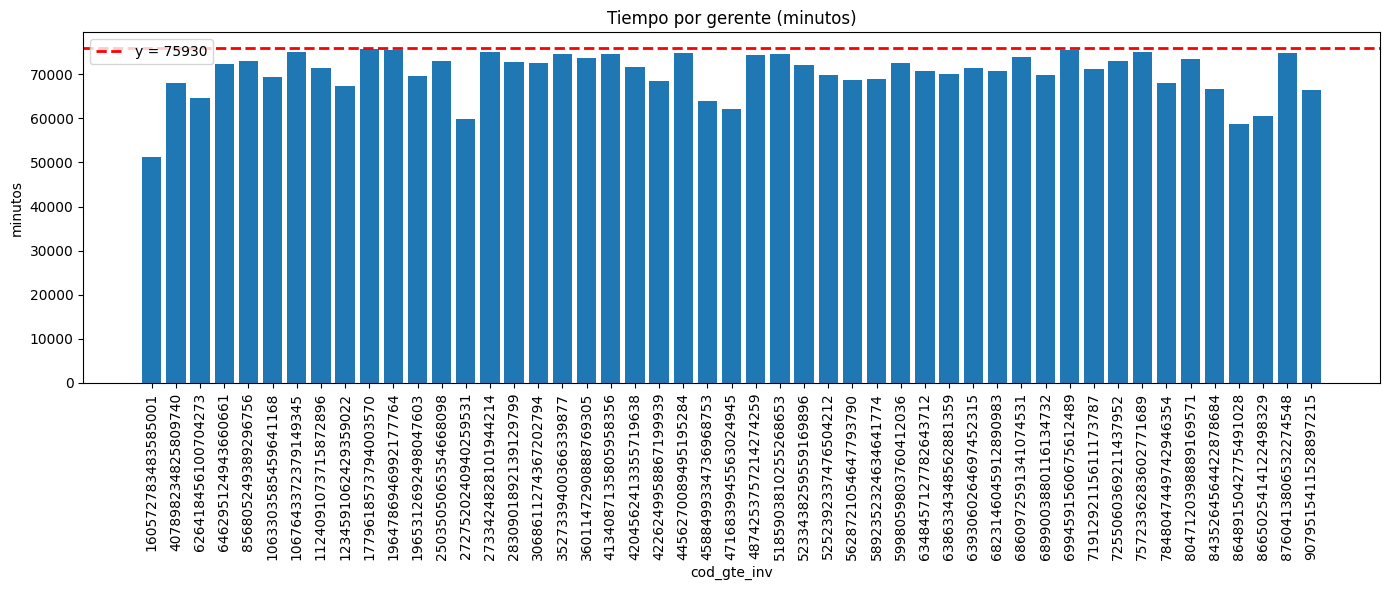

In [39]:
import matplotlib.pyplot as plt

df = tiempo_gerente.copy()
x = df['cod_gte_inv'].astype(str)
y = df['minutos']

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x, y, color='C0')
ax.axhline(75930, color='red', linestyle='--', linewidth=2, label='y = 75930')
ax.set_xlabel('cod_gte_inv')
ax.set_ylabel('minutos')
ax.set_title('Tiempo por gerente (minutos)')
ax.tick_params(axis='x', rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

In [54]:
clientes_asignados_modelo = merge_gerente_asig[merge_gerente_asig['marca_mac_inv'].isin(['A','B'])].shape[0]
clientes_x_asignar_ab = dict_dataframes['pcac_mac_gpi_clientes'][dict_dataframes['pcac_mac_gpi_clientes']['marca_mac_inv'].isin(['A','B'])].shape[0]


metrica_asignacion_modelo = clientes_asignados_modelo / dict_dataframes['pcac_mac_gpi_clientes'].shape[0]
metrica_asignacion_real = clientes_x_asignar_ab / dict_dataframes['pcac_mac_gpi_clientes'].shape[0]

print(f'Métrica de asignación modelo: {metrica_asignacion_modelo:.4f}')
print(f'Métrica de asignación real: {metrica_asignacion_real:.4f}')

Métrica de asignación modelo: 0.3616
Métrica de asignación real: 0.5337
